## Brightness and LIME image explainer

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import mark_boundaries
from skimage.io import imsave, imshow
from astroExplain.image.neighbors import Neighbors
from astroExplain.image.explanation import TellMeWhy
from sdss.utils.managefiles import FileDirectory


# Custom functions

## Segment

In [ ]:
def segment(image, sigma, compactness, nsegments):

    slic_parameters = {"sigma": sigma, "compactness": compactness}

    nghs = Neighbors(
        image=image,
        number_segments=nsegments,
        slic_parameters=slic_parameters,
        random_seed=0,
    )

    image_with_boundaries = mark_boundaries(
        nghs.image,
        nghs.segments,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    return image_with_boundaries, nghs

## Masking

In [20]:
def mask_pertrubed_sps(
    segments: np.array, on_off_super_pixels: np.array
) -> np.array:
    """
    Obtain a mask with the number of the segment for perturbed
    super pixels. The non-perturbed super pixels has a segment
    number of zero. Remember that the number of the original
    segments range from 1 to the number of segments
    """
    new_segments = segments.copy()
    for idx_sp, on_off in enumerate(on_off_super_pixels):

        if on_off == 1:
            # segments range from 0 to the number of segments
            # that is why I use idx_sp + 1
            mask_on_sp = np.where(segments == idx_sp + 1, True, False)

            new_segments[mask_on_sp] = 0

    return new_segments

# Config

## Directories

In [97]:
data_dir = 'data/hoag'
explainers_dir = f'{data_dir}/explainers'
thesis_dir = '/home/elom/phd/thesis/chapters'
ch_2_dir = f'{thesis_dir}/02_figures'

## Data

In [6]:
hoag_img = plt.imread(f"{data_dir}/hoag.jpg") / 255.0

(-0.5, 562.5, 550.5, -0.5)

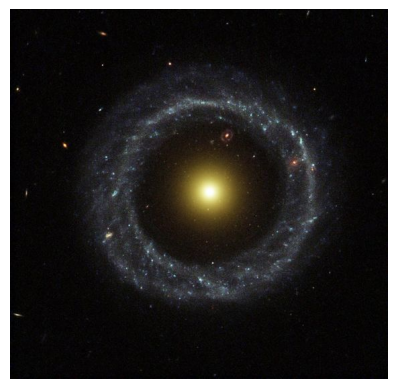

In [10]:
plt.imshow(hoag_img)
plt.axis('off')

# Squared like: compactness = 100

(-0.5, 562.5, 550.5, -0.5)

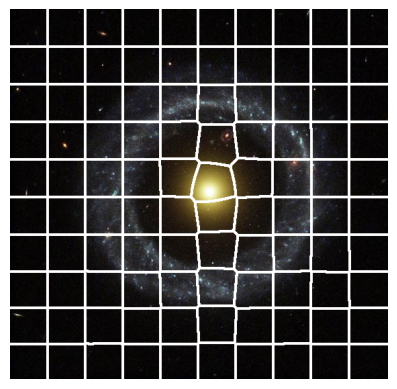

In [55]:
img_bounds_c_100, nghs = segment(
    hoag_img, sigma=16, compactness=100, nsegments=100
)
plt.imshow(img_bounds_c_100)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

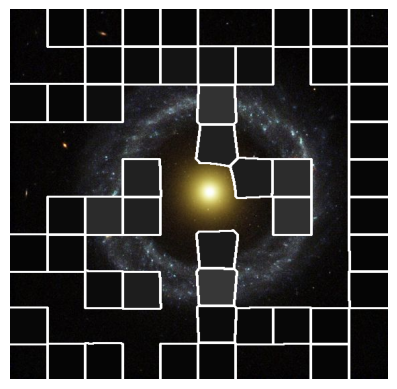

In [61]:
# selection
# n = [8, 2]
slic_parameters = {"sigma": 16, "compactness": 100}

neighbors_c_100 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_100, on_off_sp_pert_c_100
) = neighbors_c_100.get_neighbors(10, None)
# 
n = 8
new_segments_c_100 = mask_pertrubed_sps(
    neighbors_c_100.segments, on_off_sp_pert_c_100[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_100[n],
    new_segments_c_100,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')

## Selection

In [58]:
img_c_100_dict = {
    'boundaries': img_bounds_c_100,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [8, 2]):

    new_segments_c_100 = mask_pertrubed_sps(
        neighbors_c_100.segments, on_off_sp_pert_c_100[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_100[n],
        new_segments_c_100,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_100_dict[key] = img_bounds_n

(-0.5, 562.5, 550.5, -0.5)

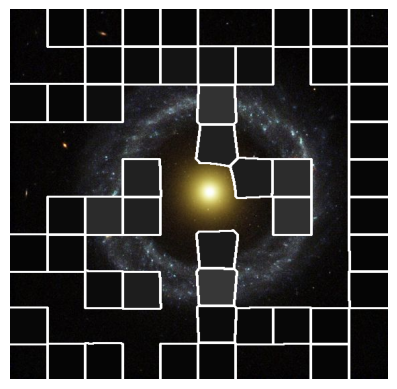

In [62]:
plt.imshow(img_c_100_dict['n1'])
plt.axis('off')

# intermediate: compactness = 10

(-0.5, 562.5, 550.5, -0.5)

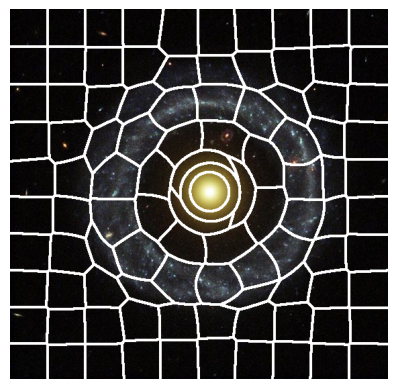

In [66]:
img_bounds_c_10, nghs = segment(
    hoag_img, sigma=16, compactness=10, nsegments=100
)
plt.imshow(img_bounds_c_10)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

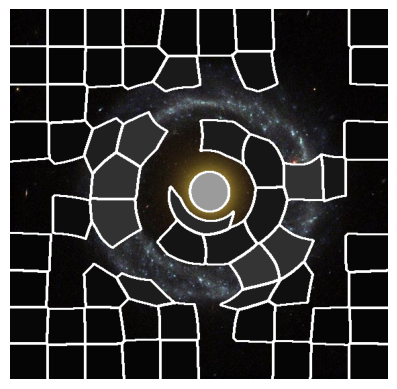

In [ ]:
# selection
# n = [2, 1]
slic_parameters = {"sigma": 16, "compactness": 10}

neighbors_c_10 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_10, on_off_sp_pert_c_10
) = neighbors_c_10.get_neighbors(10, None)
# 
n = 1
new_segments_c_10 = mask_pertrubed_sps(
    neighbors_c_10.segments, on_off_sp_pert_c_10[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_10[n],
    new_segments_c_10,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')

## Selection

In [67]:
img_c_10_dict = {
    'boundaries': img_bounds_c_10,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [2, 1]):

    new_segments_c_10 = mask_pertrubed_sps(
        neighbors_c_10.segments, on_off_sp_pert_c_10[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_10[n],
        new_segments_c_10,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_10_dict[key] = img_bounds_n

(-0.5, 562.5, 550.5, -0.5)

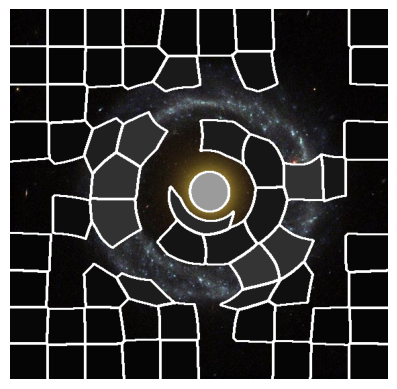

In [70]:
plt.imshow(img_c_10_dict['n2'])
plt.axis('off')

# High: compactness = 1

(-0.5, 562.5, 550.5, -0.5)

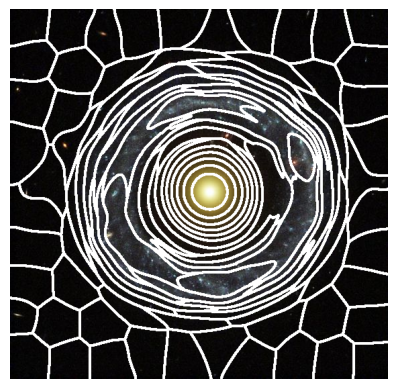

In [72]:
img_bounds_c_1, nghs = segment(
    hoag_img, sigma=16, compactness=1, nsegments=100
)
plt.imshow(img_bounds_c_1)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

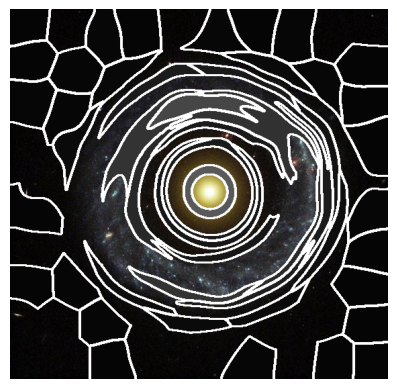

In [80]:
# selection
# n = [8, 7]
slic_parameters = {"sigma": 16, "compactness": 1}

neighbors_c_1 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_1, on_off_sp_pert_c_1
) = neighbors_c_1.get_neighbors(10, None)
# 
n = 8
new_segments_c_1 = mask_pertrubed_sps(
    neighbors_c_1.segments, on_off_sp_pert_c_1[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_1[n],
    new_segments_c_1,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')


## Selection

In [83]:
img_c_1_dict = {
    'boundaries': img_bounds_c_1,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [8, 7]):

    new_segments_c_1 = mask_pertrubed_sps(
        neighbors_c_1.segments, on_off_sp_pert_c_1[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_1[n],
        new_segments_c_1,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_1_dict[key] = img_bounds_n

(551, 563, 3)

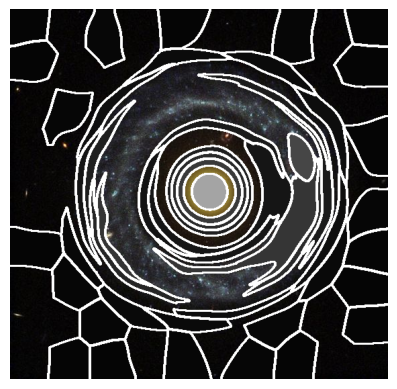

In [86]:
plt.imshow(img_c_1_dict['n2'])
plt.axis('off')
img_c_1_dict['n2'].shape

# Thesis figure

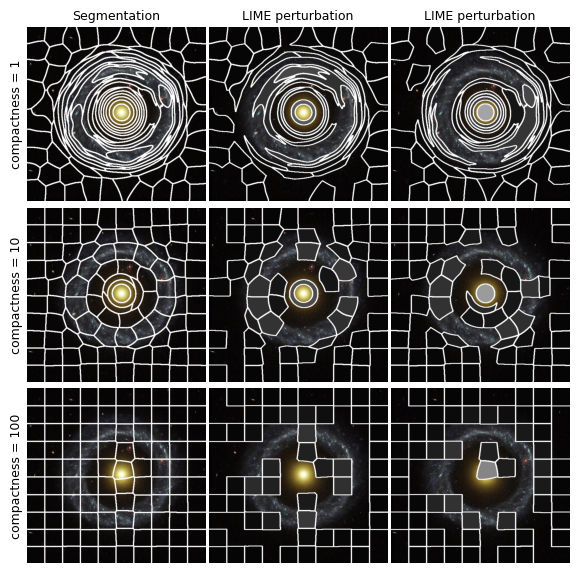

In [180]:
fig, axs = plt.subplots(
    3, 3, 
    figsize=(7, 7), 
    gridspec_kw={'wspace': 0.02, 'hspace': 0.02}
)

# 1. Group your dictionaries to represent the rows
strategy_dicts = [img_c_1_dict, img_c_10_dict, img_c_100_dict]

# 2. Define the exact order of the columns
column_keys = ['boundaries', 'n1', 'n2']

# 3. Loop through and plot
for row_idx, current_dict in enumerate(strategy_dicts):
    for col_idx, key in enumerate(column_keys):
        
        # Extract the image array
        img_array = current_dict[key]
        
        # Plot the image on the specific subplot
        axs[row_idx, col_idx].imshow(img_array)
        
        # Turn off the axes to keep it pristine
        axs[row_idx, col_idx].axis('off')


# 1. Add Column Titles to the top row (row index 0)
col_titles = ['Segmentation', 'LIME perturbation', 'LIME perturbation']
for col_idx, title in enumerate(col_titles):
    axs[0, col_idx].set_title(title, fontsize=9, pad=5)

# 2. Add Row Labels to the left-most column (col index 0)
row_labels = ['compactness = 1', 'compactness = 10', 'compactness = 100']
for row_idx, label in enumerate(row_labels):
    axs[row_idx, 0].text(
        -0.02, 0.5,
        label,
        transform=axs[row_idx, 0].transAxes, # Anchor to the axis
        rotation=90, ha='right', va='center', 
        fontsize=9,
    )

# save fig
fig.savefig(
    f"{ch_2_dir}/hoag/hoag_seg_pert_all.pdf",
    bbox_inches='tight'
)

# Good explanations

In [109]:
good_explainers_dict = {
    'c1':'weird_hide_0.08_base_mean_100_compactness_1.pkl',
    'c10':'weird_hide_0.08_base_mean_100_compactness_10.pkl',
    'c100': 'weird_hide_0.08_base_mean_100_compactness_100.pkl'
}

good_explanations_dict = {}

for compactness, explainer_pkl in good_explainers_dict.items():

    with open(f"{explainers_dir}/{explainer_pkl}", "rb") as file:

        explainer = pickle.load(file)
        why = TellMeWhy(explainer)

    weights_map = why.get_heatmap()
    weights_map *= 1 / np.nanmax(np.abs(weights_map))
    good_explanations_dict[compactness] = weights_map 

Get heat map of explanation
Get heat map of explanation
Get heat map of explanation


(-0.5, 562.5, 550.5, -0.5)

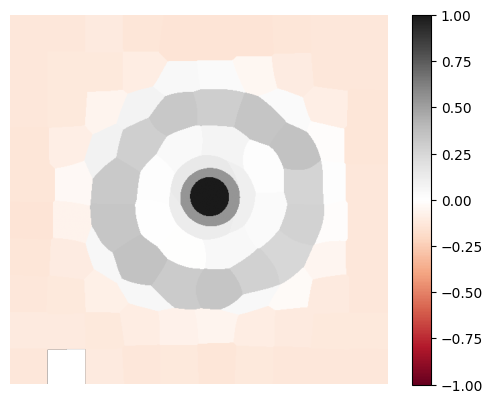

In [114]:
compactness = 'c10'
plt.imshow(good_explanations_dict[compactness], cmap="RdGy", vmin=-1, vmax=1)
cbar = plt.colorbar()
plt.axis('off')

## Figure

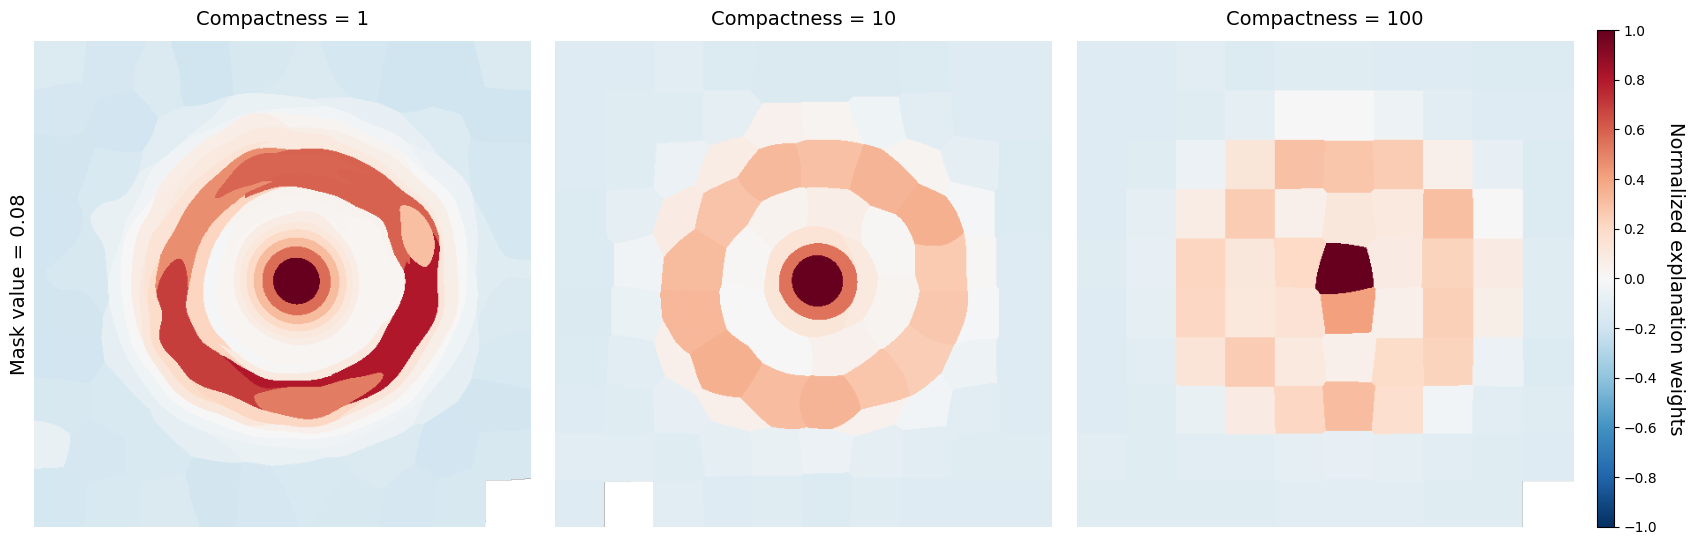

In [156]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'wspace': 0.05})

keys_order = ['c1', 'c10', 'c100']
cmap = "RdBu_r"

for i, key in enumerate(keys_order):
    
    im = axs[i].imshow(good_explanations_dict[key], cmap=cmap, vmin=-1, vmax=1)
    
    axs[i].axis('off')

cbar = fig.colorbar(
    im, ax=axs.ravel().tolist(),
    fraction=0.015, pad=0.08,
    aspect=30, shrink=1.075,
    ticks=np.linspace(-1, 1, 11)
)

cbar.set_label('Normalized explanation weights', rotation=270, labelpad=20, fontsize=14)

titles = ['Compactness = 1', 'Compactness = 10', 'Compactness = 100']
for i, title in enumerate(titles):

    axs[i].set_title(title, fontsize=14, pad=12)

axs[0].text(
    -0.01, 0.5,
    'Mask value = 0.08', 
    transform=axs[0].transAxes,
    rotation=90, va='center', ha='right', 
    fontsize=14
)

plt.subplots_adjust(left=0.02, right=0.875, top=0.95, bottom=0.02)
fig.savefig(
    f"{ch_2_dir}/hoag/good_explanations.pdf",
    bbox_inches='tight'
)


# Bad explanation

In [157]:
different_masking_explainers_dict = {
    'good':'weird_hide_0.08_base_mean_100_compactness_10.pkl',
    'bad': 'weird_hide_none_base_mean_100_compactness_10.pkl'
}

compare_explanations_dict = {}

for good_bad, explainer_pkl in different_masking_explainers_dict.items():

    with open(f"{explainers_dir}/{explainer_pkl}", "rb") as file:

        explainer = pickle.load(file)
        why = TellMeWhy(explainer)

    weights_map = why.get_heatmap()
    weights_map *= 1 / np.nanmax(np.abs(weights_map))
    compare_explanations_dict[good_bad] = weights_map 

Get heat map of explanation
Get heat map of explanation


(-0.5, 562.5, 550.5, -0.5)

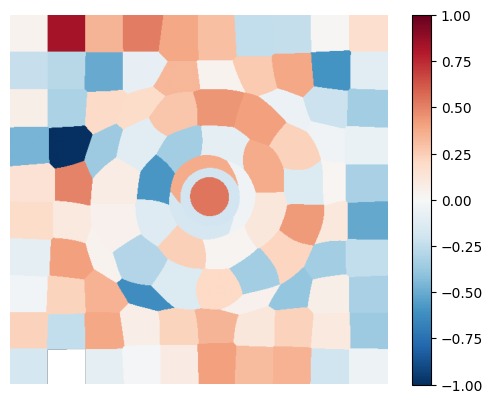

In [158]:
good_bad = 'bad'
plt.imshow(compare_explanations_dict[good_bad], cmap="RdBu_r", vmin=-1, vmax=1)
cbar = plt.colorbar()
plt.axis('off')

## Figure

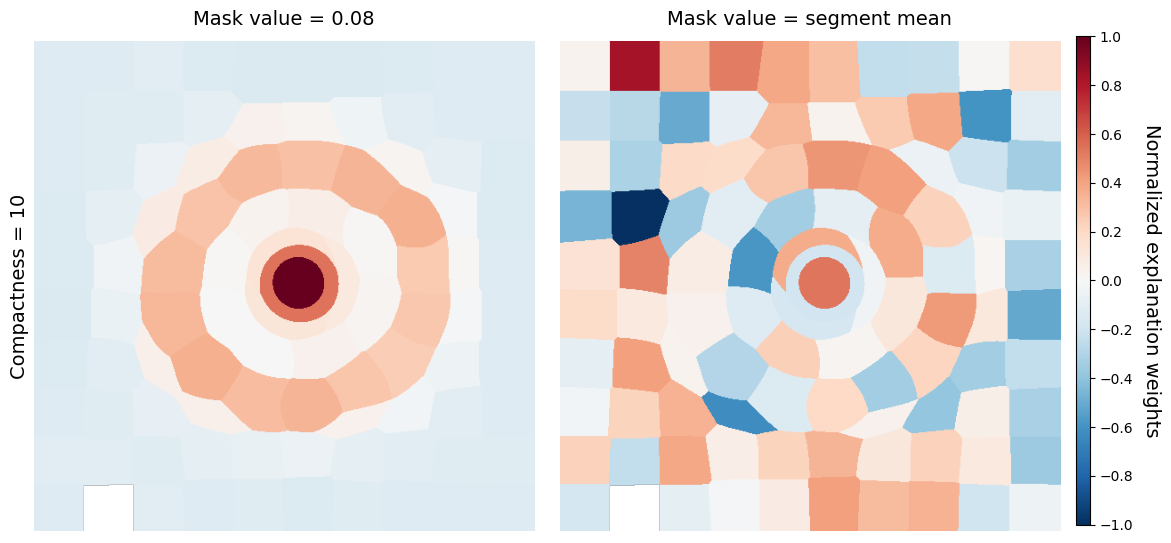

In [177]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.05})

keys_order = ['good', 'bad']
cmap = "RdBu_r"

for i, key in enumerate(keys_order):
    
    im = axs[i].imshow(compare_explanations_dict[key], cmap=cmap, vmin=-1, vmax=1)
    
    axs[i].axis('off')

cbar = fig.colorbar(
    im, ax=axs.ravel().tolist(),
    fraction=0.015, pad=0.08,
    aspect=35, shrink=1.1,
    ticks=np.linspace(-1, 1, 11)
)

cbar.set_label('Normalized explanation weights', rotation=270, labelpad=20, fontsize=14)

titles = ['Mask value = 0.08', 'Mask value = segment mean']
for i, title in enumerate(titles):

    axs[i].set_title(title, fontsize=14, pad=12)

axs[0].text(
    -0.01, 0.5,
    'Compactness = 10', 
    transform=axs[0].transAxes,
    rotation=90, va='center', ha='right', 
    fontsize=14
)

plt.subplots_adjust(left=0.02, right=0.875, top=0.95, bottom=0.02)
fig.savefig(
    f"{ch_2_dir}/hoag/good_bad_explanations.pdf",
    bbox_inches='tight'
)
